# single-load

In [1]:
%load_ext autoreload
%autoreload 2

%pip install -r requirements.txt
%pip install -e .
%pip install matplotlib

import selfmade.nb101 as nb101
import selfmade.nbcore as nbcore

records = r'.\datas\nasbench_full.tfrecord'
space = nb101.NASBench101Space()
evaluator = nb101.NASBench101Evaluator(records, space)

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'f:\vinh\vscs\fi\venv37\Scripts\python.exe -m pip install --upgrade pip' command.


Obtaining file:///F:/vinh/vscs/fi
  Attempting uninstall: nasbench
    Found existing installation: nasbench 1.0
    Uninstalling nasbench-1.0:
      Successfully uninstalled nasbench-1.0
  Running setup.py develop for nasbench
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'f:\vinh\vscs\fi\venv37\Scripts\python.exe -m pip install --upgrade pip' command.


Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'f:\vinh\vscs\fi\venv37\Scripts\python.exe -m pip install --upgrade pip' command.





Loading dataset from file... This may take a few minutes...
Instructions for updating:
Use eager execution and: 
`tf.data.TFRecordDataset(path)`
Loaded dataset in 128 seconds


In [2]:
from sklearn.ensemble import RandomForestRegressor
import secrets
import matplotlib.pyplot as plt
import pandas as pd

# main functions

In [3]:
# Full vanilla (100 evals -> 10 pop, 10 iters)
def vanilla_run(loops, pop):
    pop.evolve_loop(total_gen=loops)
    return pop

In [7]:
# Half vanilla, half guided (100 evals -> 10 pop, 5 val, 5 gui)
def guided_run(loops, pop):
    split = int(loops/2)
    print("Half vanilla")
    pop.evolve_loop(total_gen=split)

    rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=1)
    fi = nbcore.FeatureImportance(space)
    imp = fi.pipeline(pop.data, rf)

    gui = nbcore.Guidance(space, imp, pop.config)
    gui.sortNsplit()
    gui.calculate_guidance()

    print("Half guided")
    pop.evolve_loop(total_gen=split, guidance = gui)
    return pop


# test run

In [9]:
pop_size = 100
total_gen = 20
# Set seed và population chung để tạo tính công bằng cho 2 lượt chạy khác nhau
nb101.set_seed(42)
share_pop = nbcore.Population(pop_size, space, evaluator)
share_pop.initialize()

Best performance: 0.9458132982254028
Recording generation 0
Finished recording


In [ ]:
fv = vanilla_run(total_gen, share_pop)
sv = guided_run(total_gen, share_pop)

AttributeError: 'Population' object has no attribute 'copy'

# plot on full vanilla (test run first)

In [ ]:
int_ticks = range(0, total_gen + 1, 2)

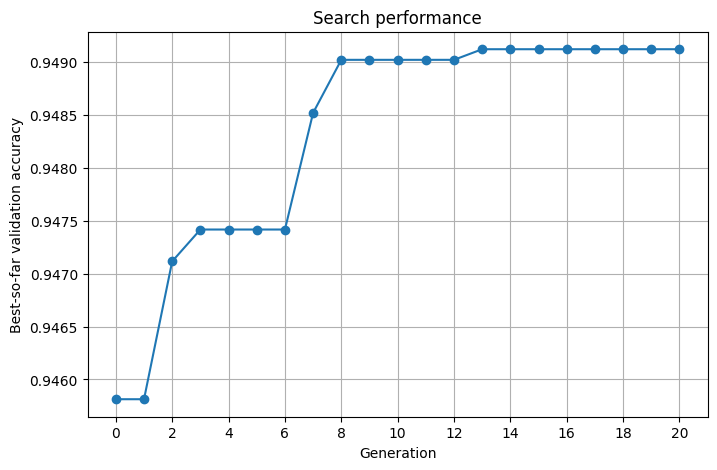

In [ ]:
hist = pd.DataFrame(fv.best_history)

plt.figure(figsize=(8, 5))
plt.plot(
    hist["generation"],
    hist["best_so_far"],
    marker="o"
)
plt.xticks(int_ticks)
plt.xlabel("Generation")
plt.ylabel("Best-so-far validation accuracy")
plt.title("Search performance")
plt.grid(True)
plt.show()

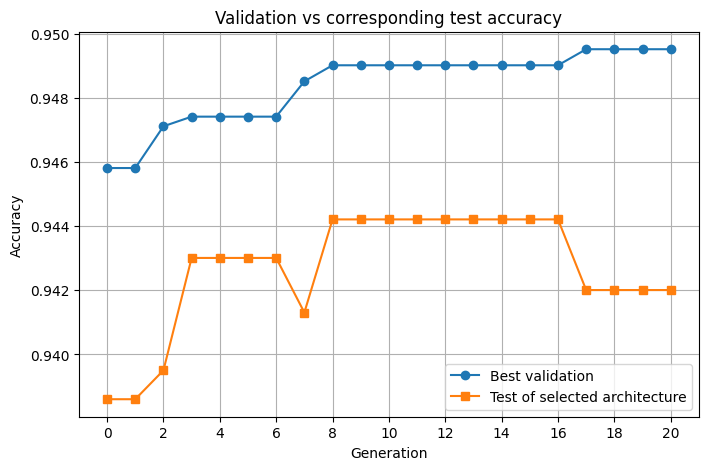

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    hist["generation"],
    hist["best_val"],
    marker="o",
    label="Best validation"
)

plt.plot(
    hist["generation"],
    hist["best_test"],
    marker="s",
    label="Test of selected architecture"
)
plt.xticks(int_ticks)
plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.title("Validation vs corresponding test accuracy")
plt.legend()
plt.grid(True)
plt.show()

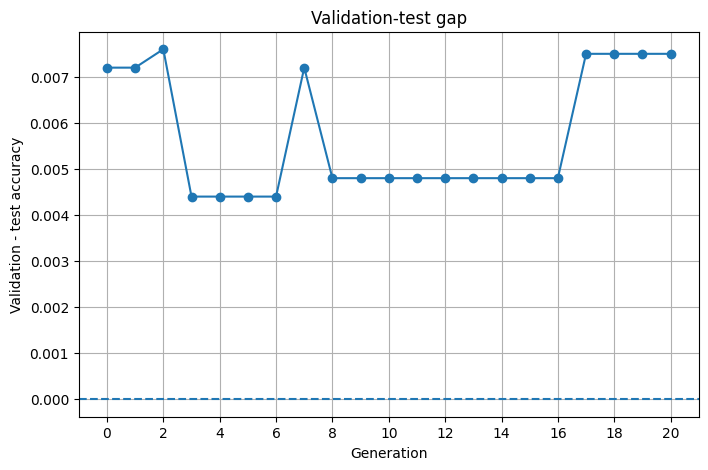

In [ ]:
hist["val_test_gap"] = (
    hist["best_val"] - hist["best_test"]
)

plt.figure(figsize=(8, 5))
plt.plot(
    hist["generation"],
    hist["val_test_gap"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xticks(int_ticks)
plt.xlabel("Generation")
plt.ylabel("Validation - test accuracy")
plt.title("Validation-test gap")
plt.grid(True)
plt.show()

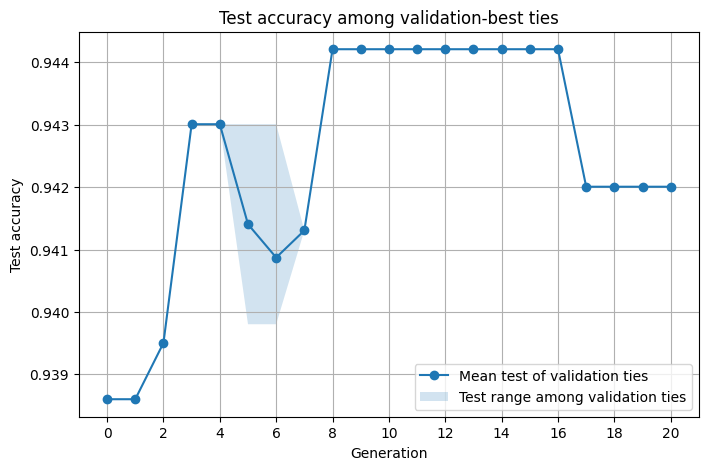

In [ ]:
plt.figure(figsize=(8, 5))

x = hist["generation"]

plt.plot(
    x,
    hist["tied_test_mean"],
    marker="o",
    label="Mean test of validation ties"
)

plt.fill_between(
    x,
    hist["tied_test_min"],
    hist["tied_test_max"],
    alpha=0.2,
    label="Test range among validation ties"
)

plt.xticks(int_ticks)
plt.xlabel("Generation")
plt.ylabel("Test accuracy")
plt.title("Test accuracy among validation-best ties")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df = pd.DataFrame(fv.data)

population_stats = (
    df.groupby("generation")["validation_accuracy"]
      .agg(["mean", "median", "min", "max"])
      .reset_index()
)

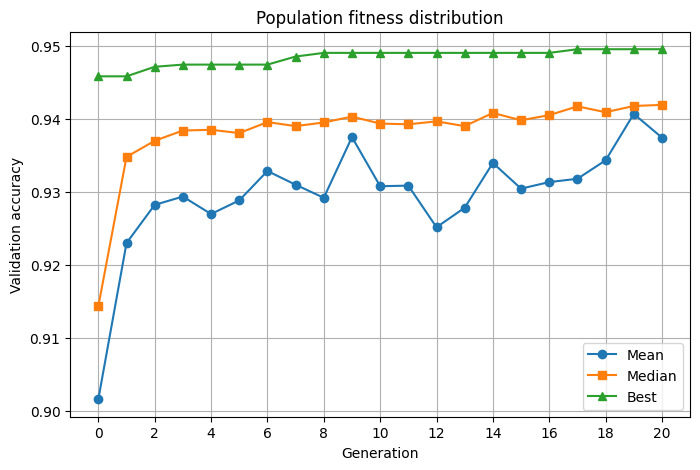

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    population_stats["generation"],
    population_stats["mean"],
    marker="o",
    label="Mean"
)

plt.plot(
    population_stats["generation"],
    population_stats["median"],
    marker="s",
    label="Median"
)

plt.plot(
    population_stats["generation"],
    population_stats["max"],
    marker="^",
    label="Best"
)

plt.xticks(int_ticks)
plt.xlabel("Generation")
plt.ylabel("Validation accuracy")
plt.title("Population fitness distribution")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
def genome_signature(rep):
    return (
        rep["code"],
        tuple(rep["operations"])
    )

In [ ]:
df["signature"] = df["representation"].apply(genome_signature)

diversity = (
    df.groupby("generation")["signature"]
      .nunique()
      .reset_index(name="unique_architectures")
)

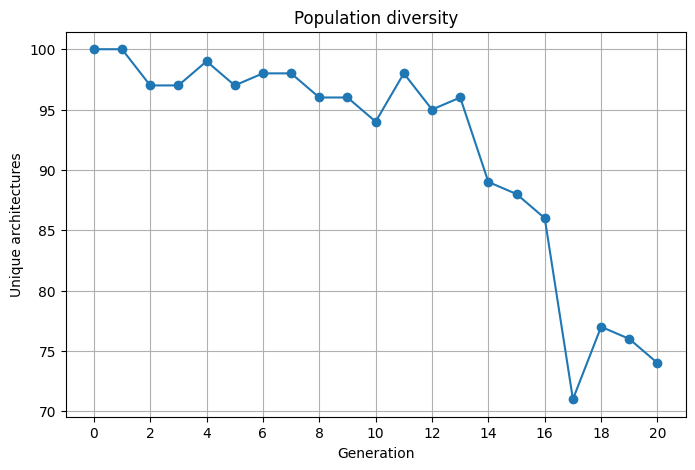

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    diversity["generation"],
    diversity["unique_architectures"],
    marker="o"
)

plt.xticks(int_ticks)
plt.xlabel("Generation")
plt.ylabel("Unique architectures")
plt.title("Population diversity")
plt.grid(True)
plt.show()

# plot on vanilla + guided

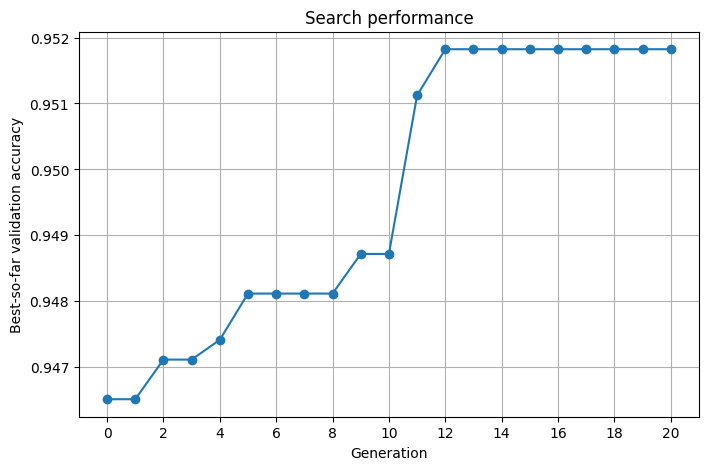

In [ ]:
hist = pd.DataFrame(sv.best_history)

plt.figure(figsize=(8, 5))
plt.plot(
    hist["generation"],
    hist["best_so_far"],
    marker="o"
)

plt.xticks(int_ticks)
plt.xlabel("Generation")
plt.ylabel("Best-so-far validation accuracy")
plt.title("Search performance")
plt.grid(True)
plt.show()

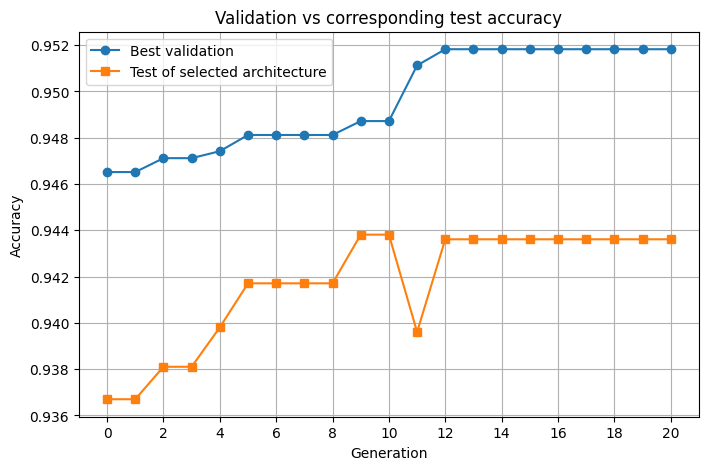

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    hist["generation"],
    hist["best_val"],
    marker="o",
    label="Best validation"
)

plt.plot(
    hist["generation"],
    hist["best_test"],
    marker="s",
    label="Test of selected architecture"
)

plt.xticks(int_ticks)
plt.xlabel("Generation")
plt.ylabel("Accuracy")
plt.title("Validation vs corresponding test accuracy")
plt.legend()
plt.grid(True)
plt.show()

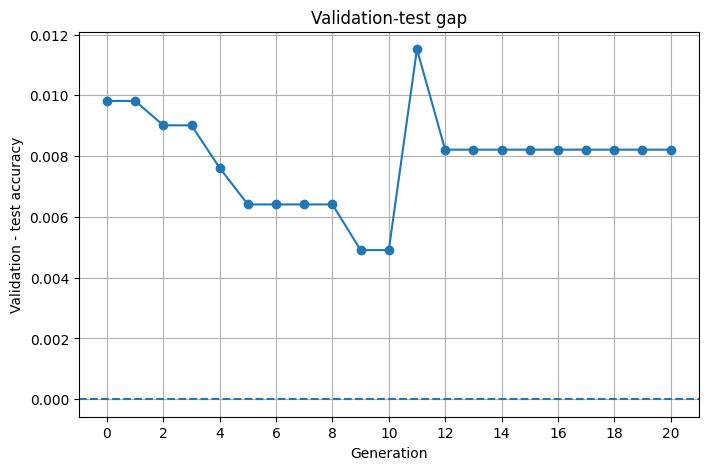

In [ ]:
hist["val_test_gap"] = (
    hist["best_val"] - hist["best_test"]
)

plt.figure(figsize=(8, 5))
plt.plot(
    hist["generation"],
    hist["val_test_gap"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.xticks(int_ticks)
plt.xlabel("Generation")
plt.ylabel("Validation - test accuracy")
plt.title("Validation-test gap")
plt.grid(True)
plt.show()

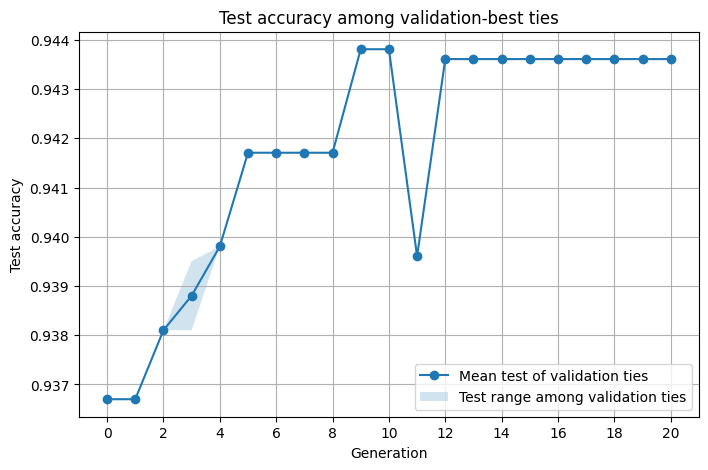

In [ ]:
plt.figure(figsize=(8, 5))

x = hist["generation"]

plt.plot(
    x,
    hist["tied_test_mean"],
    marker="o",
    label="Mean test of validation ties"
)

plt.fill_between(
    x,
    hist["tied_test_min"],
    hist["tied_test_max"],
    alpha=0.2,
    label="Test range among validation ties"
)

plt.xticks(int_ticks)
plt.xlabel("Generation")
plt.ylabel("Test accuracy")
plt.title("Test accuracy among validation-best ties")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df = pd.DataFrame(sv.data)

population_stats = (
    df.groupby("generation")["validation_accuracy"]
      .agg(["mean", "median", "min", "max"])
      .reset_index()
)

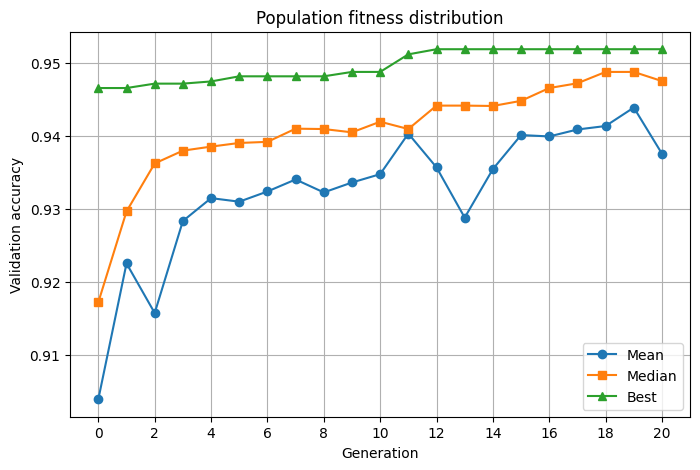

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    population_stats["generation"],
    population_stats["mean"],
    marker="o",
    label="Mean"
)

plt.plot(
    population_stats["generation"],
    population_stats["median"],
    marker="s",
    label="Median"
)

plt.plot(
    population_stats["generation"],
    population_stats["max"],
    marker="^",
    label="Best"
)

plt.xticks(int_ticks)
plt.xlabel("Generation")
plt.ylabel("Validation accuracy")
plt.title("Population fitness distribution")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
df["signature"] = df["representation"].apply(genome_signature)

diversity = (
    df.groupby("generation")["signature"]
      .nunique()
      .reset_index(name="unique_architectures")
)

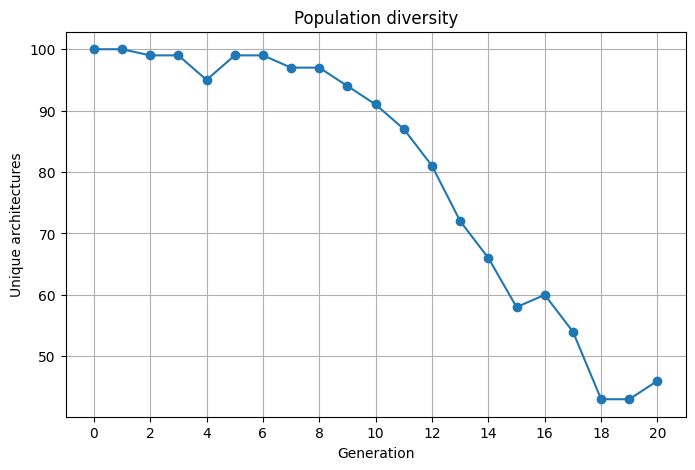

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    diversity["generation"],
    diversity["unique_architectures"],
    marker="o"
)

plt.xticks(int_ticks)
plt.xlabel("Generation")
plt.ylabel("Unique architectures")
plt.title("Population diversity")
plt.grid(True)
plt.show()

# seed loop

In [65]:
def loopy_loop(n_runs, size, loops):
    fv_seed = []
    sv_seed = []
    seeds = []

    for run in range(n_runs):
        s = secrets.randbits(32)
        seeds.append(s)

        print(f"Running {run + 1}/{n_runs} | seed = {s}")

        nb101.set_seed(s)

        fv = vanilla_run(size, loops)
        fv_seed.append(fv)

        sv = guided_run(size, loops)
        sv_seed.append(sv)

    return fv_seed, sv_seed, seeds

In [105]:
runs = 50
pop = 100
evo = 30
fv, sv, seeds = loopy_loop(runs, pop, evo)
# fv, sv, seeds = loopy_loop(20, pop_size * 2, 50)

Running 1/50 | seed = 3908889332
Best performance: 0.9435096383094788
Recording generation 0
Finished recording
Generation 1 - Best performance: 0.9437099099159241
Recording generation 1
Finished recording
Generation 2 - Best performance: 0.9437099099159241
Recording generation 2
Finished recording
Generation 3 - Best performance: 0.9471153616905212
Recording generation 3
Finished recording
Generation 4 - Best performance: 0.9471153616905212
Recording generation 4
Finished recording
Generation 5 - Best performance: 0.9471153616905212
Recording generation 5
Finished recording
Generation 6 - Best performance: 0.9472155570983887
Recording generation 6
Finished recording
Generation 7 - Best performance: 0.9472155570983887
Recording generation 7
Finished recording
Generation 8 - Best performance: 0.9472155570983887
Recording generation 8
Finished recording
Generation 9 - Best performance: 0.9472155570983887
Recording generation 9
Finished recording
Generation 10 - Best performance: 0.947215

In [106]:
def make_history_df(runs, seeds, method):
    rows = []

    for pop, seed in zip(runs, seeds):
        for h in pop.best_history:
            rows.append({
                "seed": seed,
                "method": method,
                "generation": h["generation"],
                "best_val": h["best_val"],
                "best_so_far": h["best_so_far"],
                "best_test": h["best_test"],
                "tied_test_min": h["tied_test_min"],
                "tied_test_max": h["tied_test_max"],
                "tied_test_mean": h["tied_test_mean"],
                "num_tied": h["num_tied"],
            })

    return pd.DataFrame(rows)

In [107]:
vanilla_df = make_history_df(fv,seeds,"Vanilla")
guided_df = make_history_df(sv,seeds,"Guided")

history_df = pd.concat([vanilla_df, guided_df],ignore_index=True)

In [108]:
import numpy as np

def summarize(df):
    summary = (
        df.groupby(["method", "generation"])["best_so_far"]
        .agg(["mean", "std", "count"])
        .reset_index()
    )

    summary["sem"] = (
        summary["std"] /
        np.sqrt(summary["count"])
    )

    summary["ci95"] = 1.96 * summary["sem"]

    return summary

In [109]:
ticks = range(0, evo + 1, 2)

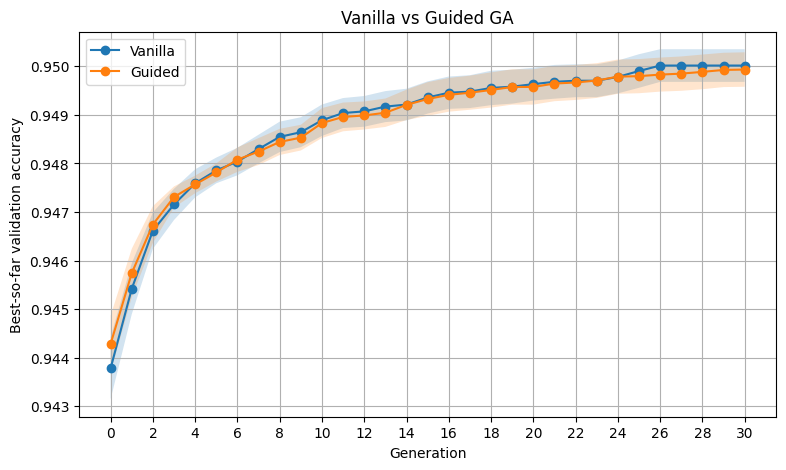

In [110]:
summary = summarize(history_df)

plt.figure(figsize=(9, 5))

for method in ["Vanilla", "Guided"]:
    d = summary[summary["method"] == method]

    plt.plot(
        d["generation"],
        d["mean"],
        marker="o",
        label=method
    )

    plt.fill_between(
        d["generation"],
        d["mean"] - d["ci95"],
        d["mean"] + d["ci95"],
        alpha=0.2
    )

plt.xticks(ticks)
plt.xlabel("Generation")
plt.ylabel("Best-so-far validation accuracy")
plt.title("Vanilla vs Guided GA")
plt.legend()
plt.grid(True)
plt.show()

In [111]:
def final_results(df):
    final = (
        df.sort_values("generation")
        .groupby(["seed", "method"])
        .tail(1)
    )

    return final

In [112]:
final = final_results(history_df)

pivot = final.pivot(
    index="seed",
    columns="method",
    values="best_so_far"
)

pivot["improvement"] = (
    pivot["Guided"] - pivot["Vanilla"]
)

print(pivot)

method        Guided   Vanilla  improvement
seed                                       
64213881    0.949519  0.949519     0.000000
65290855    0.949519  0.949519     0.000000
166231453   0.949519  0.949519     0.000000
241393735   0.951823  0.949519     0.002304
397493507   0.951823  0.951823     0.000000
492137684   0.948918  0.949920    -0.001002
591542641   0.951823  0.951823     0.000000
624327316   0.949519  0.949920    -0.000401
690646955   0.950321  0.951823    -0.001502
845166351   0.949519  0.949519     0.000000
958190740   0.949519  0.949519     0.000000
994819697   0.951823  0.949519     0.002304
1176569974  0.949519  0.948718     0.000801
1192226582  0.951823  0.948518     0.003305
1276146596  0.951823  0.951823     0.000000
1287168245  0.948317  0.949519    -0.001202
1465428540  0.950020  0.948918     0.001102
1498200458  0.951823  0.949018     0.002805
1548861792  0.947216  0.949619    -0.002404
1620871942  0.949920  0.949519     0.000401
1653929009  0.951823  0.951823  

In [113]:
pivot["good"] = (pivot["improvement"] >= 0).astype(int)
pivot["good"].value_counts()

1    31
0    19
Name: good, dtype: int64

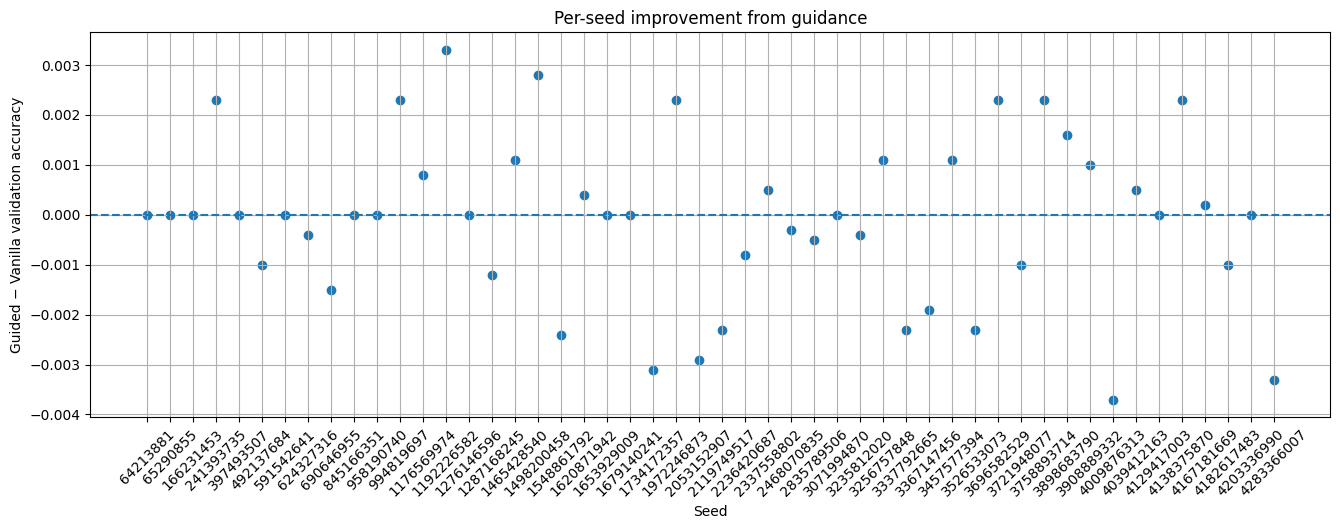

In [114]:
plt.figure(figsize=(16, 5))

x = np.arange(len(pivot))

plt.axhline(
    0,
    linestyle="--"
)

plt.scatter(
    x,
    pivot["improvement"]
)

plt.xticks(
    x,
    [str(s) for s in pivot.index],
    rotation=45
)

plt.xlabel("Seed")
plt.ylabel("Guided − Vanilla validation accuracy")
plt.title("Per-seed improvement from guidance")
plt.grid(True)
plt.show()

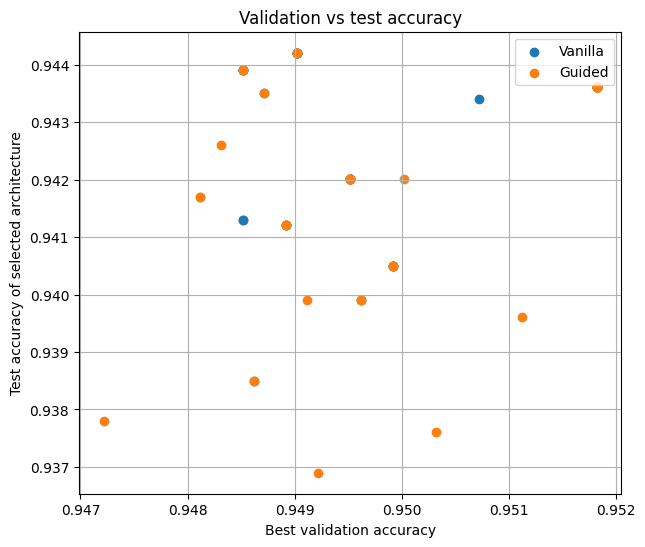

In [115]:
final_val = final.copy()

plt.figure(figsize=(7, 6))

for method in ["Vanilla", "Guided"]:
    d = final_val[final_val["method"] == method]

    plt.scatter(
        d["best_so_far"],
        d["best_test"],
        label=method
    )

plt.xlabel("Best validation accuracy")
plt.ylabel("Test accuracy of selected architecture")
plt.title("Validation vs test accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [116]:
final_val["val_test_gap"] = (
    final_val["best_so_far"]
    - final_val["best_test"]
)

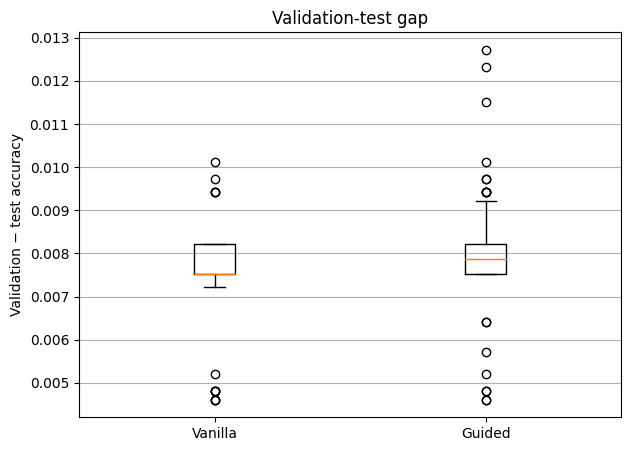

In [117]:
plt.figure(figsize=(7, 5))

groups = [
    final_val[
        final_val["method"] == "Vanilla"
    ]["val_test_gap"],

    final_val[
        final_val["method"] == "Guided"
    ]["val_test_gap"]
]

plt.boxplot(
    groups,
    labels=["Vanilla", "Guided"]
)

plt.ylabel("Validation − test accuracy")
plt.title("Validation-test gap")
plt.grid(True, axis="y")
plt.show()